In [1]:
# data processing
import pandas as pd
import numpy as np
from collections import Counter
import imblearn
from pylab import *
%matplotlib inline
import rasterio
from classification_aux import inpsectiontocsv
import os
import multiprocessing as mp
import rasterio as rio
import pickle as pkl
import random

# modelling
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
import joblib
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=UserWarning)

In [10]:
data_dir = '/network/scratch/m/matthew.fortier/shared/lichen/raw'
sites = os.listdir(data_dir)
test_sites = ['CG1-8B', 'F3-20B', 'CS-103A', 'ZF20-11A'] # Don't train on these
train_sites = [s for s in sites if s not in test_sites]
random.shuffle(train_sites)
non_predictive_columns = ['x_pos', 'y_pos', 'site', 'class_certainty'] # These are removed before training

In [6]:
df = pd.read_csv("dataset_file_transformed.csv")
# Use certainty 1 and 2
df_reduced = df[df['class_certainty'] <= 2]

In [22]:
# Custom train-test-split function
def split_by_sites(df, sites, split_xy=True):
    site_indices = df['site'].isin(sites)

    feature_columns = list(df.columns)
    feature_columns.remove('veg_class')

    X = df[feature_columns]
    y = df['veg_class']
    X_train = X[~site_indices].reset_index(drop=True)
    X_test = X[site_indices].reset_index(drop=True)
    y_train = y[~site_indices].reset_index(drop=True)
    y_test = y[site_indices].reset_index(drop=True)

    return X_train, X_test, y_train, y_test


# Score model on a particular CV split
def score_model(model, X_train, X_test, y_train, y_test):
    # remove irrelevant columns
    X_train = X_train.drop(columns=non_predictive_columns)
    X_test = X_test.drop(columns=non_predictive_columns)

    # data balancing
    under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = under.fit_resample(X_train, y_train)

    model.fit(X_res.values, y_res.values)
    train_accuracy = model.score(X_res, y_res)
    test_accuracy = model.score(X_test, y_test)
    
    return train_accuracy, test_accuracy


# Run all CV splits and return results
def site_cross_validation(model, train_data, cuts):
    '''
    `cuts` is a list of lists with site names used for cross validation
          ex: [ ['CS3A', 'ZF20-11A'], ['F3-20A', 'CG1-8A'], ... ]
    '''
    train_accuracies = []
    test_accuracies = []
    for cut in cuts:
        X_train, X_val, y_train, y_val = split_by_sites(train_data, cut)
        
        tr, te = score_model(model, X_train, X_val, y_train, y_val)
        
        train_accuracies.append(tr)
        test_accuracies.append(te)
        
    return train_accuracies, test_accuracies

In [24]:
def random_search(df, param_dist, n_iterations=50, n_jobs=8, train_sites=train_sites):
    
    train_data = df
    #####
    # use
    #   train_data = [df['site'].isin(train_sites)]
    # if we want to hold out a few test sites outside cross_validation
    #####
    
    cv_train_cuts = [train_sites[i:i + 4] for i in range(0, len(train_sites), 4)]
    
    for i in range(n_iterations):
        params = {key: random.choice(value) for key, value in param_dist.items()}
        print(f'Trying {params}')
        model = RandomForestClassifier(n_jobs=n_jobs, **params)
        train_accuracies, test_accuracies = site_cross_validation(model, train_data, cv_train_cuts)
        print(f'  Train accuracy: {mean(train_accuracies)}, Test accuracy: {mean(test_accuracies)}')

param_dist = {
    'n_estimators': [400, 500, 600],
    'max_depth': [6, 8, 10, 12, 14, 16, 18, 20],
    'min_samples_split': [2, 4],
    #'min_samples_leaf': [1, 2],
}

random.shuffle(sites)
random_search(df_reduced, param_dist, n_iterations=10, train_sites=sites)

Trying {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 2}
  Train accuracy: 0.7730306998026893, Test accuracy: 0.6196996321520535
Trying {'n_estimators': 600, 'max_depth': 8, 'min_samples_split': 4}
  Train accuracy: 0.7140782568277073, Test accuracy: 0.6249467210966747
Trying {'n_estimators': 600, 'max_depth': 20, 'min_samples_split': 2}
  Train accuracy: 0.9904816948216894, Test accuracy: 0.5874295017086604
Trying {'n_estimators': 500, 'max_depth': 6, 'min_samples_split': 2}
  Train accuracy: 0.6730764289323058, Test accuracy: 0.6290097030456587
Trying {'n_estimators': 600, 'max_depth': 16, 'min_samples_split': 2}
  Train accuracy: 0.9501892422452234, Test accuracy: 0.5956468416030933
Trying {'n_estimators': 400, 'max_depth': 6, 'min_samples_split': 2}
  Train accuracy: 0.6720639504194503, Test accuracy: 0.6253068847404241
Trying {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 2}
  Train accuracy: 0.7729714426482325, Test accuracy: 0.618633404440491
Trying {'n

# TODO
- 3D pointcloud visualization - RGB as axes, point colour as class
- Build custom cross validation routine w/ rotating holdout sites
  - Then rerun various over / undersampling techniques
- F1 score / different metrics for all experiments

  Train accuracy: 0.7520785460622519
  Test accuracy: 0.7179183914843288
                  0
chm        0.126620
bc         0.066265
rc+gc      0.065709
GLI        0.060813
rc         0.058878
gc         0.057813
rc/gc      0.057248
Ikaw       0.056851
MGRVI      0.056668
ExG        0.055353
ExB        0.053158
z_score_Y  0.041503
z_score_L  0.040290
ExGmExR    0.037222
G          0.031802
L          0.031297
Y          0.030566
B          0.029215
R          0.022028
ExR        0.020699


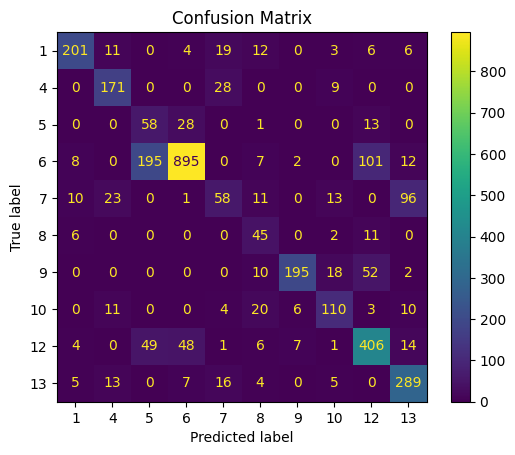

In [9]:
def run_experiment(X_train, X_test, y_train, y_test, extra_metrics=False):
    # remove irrelevant columns
    X_train = X_train.drop(columns=non_predictive_columns)
    X_test = X_test.drop(columns=non_predictive_columns)

    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = under.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    clf=RandomForestClassifier(n_estimators=500, max_depth=10, n_jobs=12)
    clf.fit(X_res.values, y_res.values)

    # -----------------------------------------------------------------------------------------------------------
    # Prediction
    preds = clf.predict(X_test.values)

    print(f'  Train accuracy: {clf.score(X_res, y_res)}')
    print(f'  Test accuracy: {clf.score(X_test, y_test)}')

    if extra_metrics:
        # -----------------------------------------------------------------------------------------------------------
        # Inspect performance parameters: training and testing scores, confusion matrix, and feature importanceax1 = plt.figure(figsize=(5,5)).add_subplot(111)

        cf_matrix = confusion_matrix(y_test, preds,  labels = clf.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=clf.classes_)
        disp.plot()
        plt.title('Confusion Matrix')

        feature_importance = pd.DataFrame(clf.feature_importances_, index=X_res.columns).sort_values(by=0, ascending=False)
        print(feature_importance)

    return clf, preds


X_train, X_test, y_train, y_test = split_by_sites(df_reduced, test_sites)
model, _ = run_experiment(X_train, X_test, y_train, y_test, extra_metrics=True)

In [10]:
model = RandomForestClassifier(bootstrap=True, max_depth=15, min_samples_leaf=4, min_samples_split=2, n_estimators=500, n_jobs=4)

In [22]:


site_cross_validation(model, df, cv_train_site_splits)


[0.6469288555015467]
[0.6469288555015467, 0.6034698996655519]
[0.6469288555015467, 0.6034698996655519, 0.4887901043679938]
[0.6469288555015467, 0.6034698996655519, 0.4887901043679938, 0.6366689053055742]
[0.6469288555015467, 0.6034698996655519, 0.4887901043679938, 0.6366689053055742, 0.5565179731485491]


0.5864751475978431

In [118]:
df_majority = df[(df['veg_class'] == 1) & (df['class_certainty'] == 1)]
df_minority = df[(df['veg_class'] != 1) & (df['class_certainty'] <= 3)]

# Get count of minority class
minority_count = len(df_minority)

# Randomly sample from majority class to match the count of minority class
df_majority_downsampled = df_majority.sample(n=minority_count//3, random_state=42)

# Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataset
df_reduced = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)
df_reduced['veg_class'].value_counts()

veg_class
1     8381
6     7561
12    4984
10    2926
5     2293
9     1968
13    1570
8     1418
4     1235
7     1188
Name: count, dtype: int64

In [8]:
# Use certainty 1 and 2
df_reduced = df[(df['class_certainty'] <= 3)]
df_reduced['veg_class'].value_counts()
df_reduced

,site,y_pos,x_pos,veg_class,R,G,B,chm,class_certainty,rc,...,ExR,ExB,ExGmExR,Ikaw,MGRVI,GLI,Y,L,z_score_Y,z_score_L
0,CG1-8A,513,7948,13,0.878431,0.870588,0.858824,1,2,0.336842,...,0.359216,0.331765,-0.355294,0.011287,-0.008968,0.001127,0.732043,88.545070,1.099229,1.008525
1,CG1-8A,513,7949,13,0.913725,0.890196,0.870588,1,2,0.341642,...,0.389020,0.328627,-0.392941,0.024176,-0.026083,-0.001100,0.775357,90.567626,1.284370,1.127803
2,CG1-8A,514,7948,13,0.874510,0.862745,0.854902,1,2,0.337368,...,0.361569,0.334118,-0.365490,0.011338,-0.013543,-0.001135,0.719363,87.937934,1.045030,0.972720
3,CG1-8A,514,7949,13,0.894118,0.866667,0.843137,1,2,0.343373,...,0.385098,0.313725,-0.389020,0.029345,-0.031173,-0.001130,0.731132,88.501666,1.095333,1.005965
4,CG1-8A,584,9232,12,0.364706,0.419608,0.282353,1,2,0.341912,...,0.090980,-0.024314,0.101176,0.127273,0.139317,0.129288,0.133104,43.227305,-1.460867,-1.664032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28017,ZF46-45A,14786,2149,6,0.478431,0.568627,0.352941,1,2,0.341737,...,0.101176,-0.074510,0.204706,0.150943,0.171016,0.155378,0.251266,57.198524,-0.250304,-0.092241
28018,ZF46-45A,14818,3243,6,0.337255,0.419608,0.270588,2,2,0.328244,...,0.052549,-0.040784,0.178824,0.109677,0.215070,0.159892,0.129235,42.647744,-1.116514,-1.238293
28019,ZF46-45A,14818,3244,6,0.329412,0.403922,0.266667,2,2,0.329412,...,0.057255,-0.030588,0.154510,0.105263,0.201132,0.150838,0.120027,41.220361,-1.181877,-1.350717
28020,ZF46-45A,14819,3243,6,0.352941,0.427451,0.298039,2,2,0.327273,...,0.066667,-0.010196,0.137255,0.084337,0.189230,0.135417,0.136327,43.701564,-1.066169,-1.155292


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END bootstrap=False, max_depth=16, min_samples_leaf=2, min_samples_split=2, n_estimators=100;, score=0.738 total time=  30.8s
[CV 4/5] END bootstrap=True, max_depth=16, min_samples_leaf=4, min_samples_split=2, n_estimators=400;, score=0.765 total time= 1.5min
[CV 5/5] END bootstrap=False, max_depth=16, min_samples_leaf=2, min_samples_split=2, n_estimators=100;, score=0.772 total time=  41.4s
[CV 5/5] END bootstrap=True, max_depth=16, min_samples_leaf=4, min_samples_split=2, n_estimators=400;, score=0.746 total time= 1.4min
[CV 2/5] END bootstrap=True, max_depth=16, min_samples_leaf=2, min_samples_split=5, n_estimators=600;, score=0.724 total time= 2.4min
[CV 2/5] END bootstrap=False, max_depth=16, min_samples_leaf=2, min_samples_split=2, n_estimators=100;, score=0.740 total time=  43.9s
[CV 2/5] END bootstrap=True, max_depth=6, min_samples_leaf=2, min_samples_split=2, n_estimators=600;, score=0.583 total time= 1.5mi

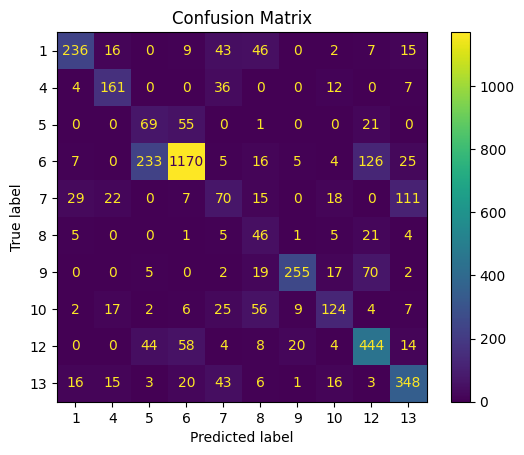

[CV 2/5] END bootstrap=False, max_depth=14, min_samples_leaf=1, min_samples_split=5, n_estimators=600;, score=0.721 total time= 3.9min
[CV 5/5] END bootstrap=False, max_depth=6, min_samples_leaf=2, min_samples_split=5, n_estimators=200;, score=0.602 total time=  37.8s
[CV 4/5] END bootstrap=True, max_depth=20, min_samples_leaf=2, min_samples_split=10, n_estimators=400;, score=0.780 total time= 1.9min
[CV 4/5] END bootstrap=True, max_depth=18, min_samples_leaf=4, min_samples_split=2, n_estimators=200;, score=0.772 total time= 1.2min
[CV 2/5] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=300;, score=0.760 total time= 2.0min
[CV 5/5] END bootstrap=False, max_depth=8, min_samples_leaf=4, min_samples_split=2, n_estimators=100;, score=0.630 total time=  23.0s
[CV 5/5] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.800 total time= 1.8min
[CV 3/5] END bootstrap=False, max_depth=8, min_samples_lea

In [11]:
# Random forest without texture data
X_train, X_test, y_train, y_test = split_by_sites(df_reduced, test_sites)
model, _ = run_experiment_random_search(X_train, X_test, y_train, y_test, extra_metrics=True)

In [ ]:
#========================
# Qualitative Evaluation
#========================

In [ ]:
site = 'CS-103A'
run_name = f'{site}_01'

# location of raw lichen data
data_dir = '/network/scratch/m/matthew.fortier/shared/lichen/raw'

# place where we stored chunked feature data
run_dir = f'/network/scratch/m/matthew.fortier/runs/{run_name}'

In [12]:
# Do some memory cleanup to make room for the beeg files
del df
del dfn
del dfn_reduced

In [14]:
site = 'CS-103A'
blocks = 4
chm = 3 # hard coded index of chm data

rgb_file = os.path.join(data_dir, site, f'{site}_hp_transparent_mosaic_group1.tif')

with rio.open(rgb_file) as f:
    meta = f.meta

curr_y = 0
curr_x = 0
h = 0
w = 0

output = np.zeros((meta['height'], meta['width']))
for y in range(blocks):
    for x in range(blocks):
        print(f'Processing block {y}-{x}')
        
        file_path = os.path.join(run_dir, 'composite', f'chunk_{y}_{x}.pkl')
        if not os.path.isfile(file_path):
            continue
    
        with open(file_path, "rb") as file:
            # Use pickle.load() to read the dictionary from the file
            block = pkl.load(file)
        h = block.shape[1]
        w = block.shape[2]
        
        block_output = np.zeros((h, w))
        
        # get coordinates of relevant pixels
        py, px = np.where(block[chm] >= 0)
        if len(py) > 0:
            features = block[:, py, px].T
            block_output[py, px] = model.predict(features)
            output[curr_y:curr_y+h, curr_x:curr_x+w] = block_output
            del features
        
        curr_x += w
        del block, block_output, py, px

    curr_x = 0
    curr_y += h
    

Processing block 0-0
Processing block 0-1
Processing block 0-2
Processing block 0-3
Processing block 1-0
Processing block 1-1
Processing block 1-2
Processing block 1-3
Processing block 2-0
Processing block 2-1
Processing block 2-2
Processing block 2-3
Processing block 3-0
Processing block 3-1
Processing block 3-2
Processing block 3-3


In [16]:
out_file = '/network/scratch/m/matthew.fortier/CS-103A-classified.tif'

meta.update(count=1)

# Write a new .tif file using the metadata from the original file
with rasterio.open(out_file, 'w', **meta) as dst:
    dst.write(output, 1)

In [ ]:
conf_matrix = confusion_matrix(y_targ, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot()

In [ ]:
pd.DataFrame(y_pred).value_counts()

In [ ]:
len(y_train)

In [ ]:
# ==========================================================================================
# Calculate permutation matrix and save figure
# ==========================================================================================
perm_importance = permutation_importance(clf, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()
print(sorted_idx)
importances = pd.DataFrame(
    perm_importance.importances[sorted_idx].T,
    columns=X.columns[sorted_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
figname = f'perm_{runname}.png'
savefig(savepath+figname, dpi=150, bbox_inches='tight')

In [ ]:
# ==========================================================================================
# save classifier in object 
# ==========================================================================================

# Add columns attribute to classifier. 
# This is important information as .tifs that should be classified need to have the same features and in the same order
clf.col_names=X.columns

# -----------------------------------------------------------------------------------------------------------
# !! careful this can make objects of several GB size
outpath = 'data/clfs/'
outfile = 'clf_%s_TEST.pkl' % run
joblib.dump(clf, outpath+outfile) 